Seed: 4778837


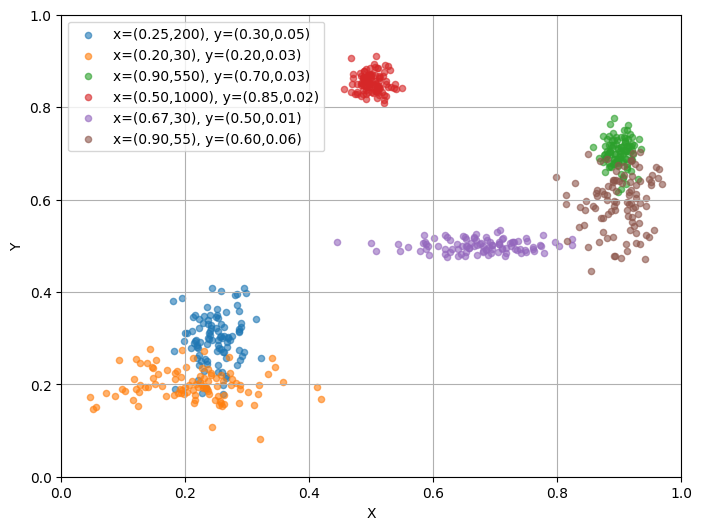

In [113]:
import numpy as np
import matplotlib.pyplot as plt

def beta_params(location, tightness):
    a = max(location * tightness, 1e-6)
    b = max((1 - location) * tightness, 1e-6)
    return a, b

# manually specify each cloud as:
# (x_location, x_tightness, y_center, y_std)
import random

def swap_y_values(specs, seed=None):
    rng = random.Random(seed)

    y_parts = [(y_center, y_std) for _, _, y_center, y_std in specs]
    rng.shuffle(y_parts)

    return [
        (x_loc, x_tight, y_center, y_std)
        for (x_loc, x_tight, _, _), (y_center, y_std) in zip(specs, y_parts)
    ]


specsMain = [
    (0.25, 200, 0.20, 0.03),
    (0.20,  30, 0.60, 0.06),
    (0.90, 550, 0.85, 0.02),
    (0.50,1000, 0.50, 0.015),
    (0.67,  30, 0.30, 0.05),
    (0.90,  55, 0.70, 0.03),
]
seed = random.randint(0, 10_000_000)
print("Seed:", seed)

# use this seed to get reproducible shuffling
# new_specs = shuffled_specs(specs, seed)
specs = swap_y_values(specsMain, seed)



# specs = [
#     (0.25, 200, 0.20, 0.03),
#     (0.20,  30, 0.30, 0.05),
#     (0.95, 550, 0.70, 0.03),
#     (0.50,1000, 0.50, 0.015),
#     (0.67,  30, 0.60, 0.06),
#     (0.90,  40, 0.85, 0.02)
# ]

n = 100
plt.figure(figsize=(8,6))

for x_loc, x_tight, y_center, y_std in specs:
    a = max(x_loc * x_tight, 1e-6)
    b = max((1 - x_loc) * x_tight, 1e-6)

    x = np.random.beta(a, b, n)
    y = np.random.normal(y_center, y_std, n)

    plt.scatter(
        x, y,
        s=20,
        alpha=0.6,
        label=f"x=({x_loc:.2f},{x_tight}), y=({y_center:.2f},{y_std:.2f})"
    )

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()